# Mathematical Engineering - Financial Engineering, FY 2025-2026
# Buy Side - Exercise 3: Covariance Estimation Techniques & Statistical Factor Models


In [86]:
# Importing the libraries
import numpy as np
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt

from utilities.backtest import backtest
from utilities.covariance_utilities import prepare_rolling_estimation_window
from utilities.portfolio_optimization import (
    mean_variance_portfolio,
    minimum_variance_portfolio,
)
from utilities.principal_component_analysis import (
    principal_component_analysis,
    align_eigenvectors_to_previous,
    pca_denoise_covariance,
)
from utilities.shrinkage import (
    constant_corr_shrinkage,
    market_factor_shrinkage,
)

from matplotlib.colors import TwoSlopeNorm

In [87]:
# Reading the data
data_path = Path("C:/Users/fabar/OneDrive/Desktop/AssignmentsFINENG/Assignment3BS_Group2/data")  # Change path

last_prices = pd.read_csv(
    data_path / "sx5e_underlyings.csv", index_col="Date", parse_dates=True
)

In [88]:
# Compute daily returns
performance = last_prices.pct_change().iloc[1:]

print(f"Dataset period: {performance.index[0].date()} to {performance.index[-1].date()}")
print(f"Number of observations: {len(performance)}")
print(f"Number of assets: {performance.shape[1]}")

Dataset period: 2013-01-03 to 2023-02-17
Number of observations: 2598
Number of assets: 50


In [89]:
# Parameters
time_horizon = 2 * 252  # 2 years of data for estimation                                    
# Parameter determining the minimum coverage of returns required for an asset to be included
# in the optimization process
min_coverage = 0.95

In [90]:
# Get the last actual day in the data for each month (monthly rebalancing)
rebalance_dates = pd.DatetimeIndex(
    performance.groupby(pd.Grouper(freq="ME"))
    .apply(lambda x: x.index[-1] if len(x) > 0 else None)
    .dropna()
    .values
)

print(f"Number of rebalance dates: {len(rebalance_dates)}")
print(f"First rebalance: {rebalance_dates[0].date()}")
print(f"Last rebalance: {rebalance_dates[-1].date()}")

Number of rebalance dates: 122
First rebalance: 2013-01-31
Last rebalance: 2023-02-17


# Part I: Covariance Estimation

The sample covariance matrix is an unbiased estimator but can be noisy, especially when the number of observations $T$ is not much larger than the number of assets $N$. Shrinkage techniques improve estimation by combining the sample covariance with a structured target.

The shrunk covariance is computed as:
$$\hat{\Sigma}_{shrunk} = \delta \cdot F + (1 - \delta) \cdot S$$

where:
- $S$ is the sample covariance matrix
- $F$ is the structured target
- $\delta$ is the optimal shrinkage intensity (derived analytically)

a) Risk aversion parameter ($\gamma$) calibration.

In [91]:
mean_variance_risk_aversion = 158 

# calibration_date is the first rebalance date for which we have a full estimation window of returns available (2y in this case)

calibration_date = None
for date in rebalance_dates:
    candidate_window = prepare_rolling_estimation_window(
        returns=performance,
        rebalance_date=date,
        lookback=time_horizon,
        min_coverage=min_coverage,
    )
    if candidate_window.shape[0] == time_horizon and candidate_window.shape[1] > 0:
        calibration_date = date 
        calibration_window = candidate_window
        break

if calibration_date is None:
    raise RuntimeError("No full estimation window available for portfolio checks")

calibration_sample_cov = calibration_window.cov()
calibration_expected_returns = calibration_window.mean(axis=0).values
ones = np.ones(calibration_sample_cov.shape[0])

calibration_mvp_weights = minimum_variance_portfolio(calibration_sample_cov.values)
calibration_mv_weights = mean_variance_portfolio(
    expected_returns=calibration_expected_returns,
    cov_matrix=calibration_sample_cov.values,
    risk_aversion=mean_variance_risk_aversion,
)

calibration_mvp_variance = float(
    calibration_mvp_weights @ calibration_sample_cov.values @ calibration_mvp_weights
)

np.testing.assert_allclose(calibration_mvp_weights.sum(), 1.0)
np.testing.assert_allclose(calibration_mv_weights.sum(), 1.0)

print(
    f"Closed-form checks on the {calibration_date.date()} rebalance window "
    f"({calibration_window.shape[1]} assets)"
)
pd.DataFrame(
    {
        "sum_weights": [calibration_mvp_weights.sum(), calibration_mv_weights.sum()],
        "in_sample_mean_return": [
            float(calibration_expected_returns @ calibration_mvp_weights),
            float(calibration_expected_returns @ calibration_mv_weights),
        ],
        "in_sample_volatility": [
            np.sqrt(calibration_mvp_variance),
            np.sqrt(
                float(
                    calibration_mv_weights
                    @ calibration_sample_cov.values
                    @ calibration_mv_weights
                )
            ),
        ],
        "gross_exposure": [
            np.abs(calibration_mvp_weights).sum(),
            np.abs(calibration_mv_weights).sum(),
        ],
    },
    index=["Minimum Variance", "Mean-Variance"],
)


Closed-form checks on the 2014-12-31 rebalance window (46 assets)


,sum_weights,in_sample_mean_return,in_sample_volatility,gross_exposure
Minimum Variance,1.0,0.000468,0.006151,2.777753
Mean-Variance,1.0,0.000851,0.006345,3.000311


b-d) Shrinkage, minimum variance and mean variance portfolios

In [92]:
constant_corr_results = {}
mkt_factor_results = {}
sample_cov_min_var_ptfs = {}
constant_corr_cov_min_var_ptfs = {}
mkt_factor_cov_min_var_ptfs = {}
sample_cov_mean_var_ptfs = {}
constant_corr_cov_mean_var_ptfs = {}
mkt_factor_cov_mean_var_ptfs = {}
window_diagnostics = {}

for rebalance_date in rebalance_dates:
    cur_performance, cur_window_diagnostics = prepare_rolling_estimation_window(
        returns=performance,
        rebalance_date=rebalance_date,
        lookback=time_horizon,
        min_coverage=min_coverage,
        return_diagnostics=True,
    )
    if (
        cur_window_diagnostics["row_count"] < time_horizon
        or cur_performance.shape[1] == 0
    ):
        continue

    print(
        f"Processing: {rebalance_date.date()} ({cur_performance.shape[1]} assets kept)"
    )
    reb_date = rebalance_date.to_pydatetime().date()

    # Market returns as equal-weighted average
    market_returns = cur_performance.mean(axis=1) # !!! COMPLETE AS APPROPRIATE !!!
    estimated_expected_returns = cur_performance.mean(axis=0) # !!! COMPLETE AS APPROPRIATE !!!

    # Compute shrinkage estimators
    cur_constant_corr_results = constant_corr_shrinkage(returns=cur_performance)
    cur_mkt_factor_results = market_factor_shrinkage(
        returns=cur_performance, market_returns=market_returns
    )

    # Compute closed-form portfolios for each covariance estimator
    sample_cov = cur_constant_corr_results["sample_cov"]
    constant_corr_cov = cur_constant_corr_results["shrunk_cov"]
    mkt_factor_cov = cur_mkt_factor_results["shrunk_cov"]

    for cov, cov_min_var_ptfs, cov_mean_var_ptfs in zip(
        [sample_cov, constant_corr_cov, mkt_factor_cov],
        [
            sample_cov_min_var_ptfs,
            constant_corr_cov_min_var_ptfs,
            mkt_factor_cov_min_var_ptfs,
        ],
        [
            sample_cov_mean_var_ptfs,
            constant_corr_cov_mean_var_ptfs,
            mkt_factor_cov_mean_var_ptfs,
        ],
    ):
        aligned_expected_returns = estimated_expected_returns.values
        cov_min_var_ptfs[reb_date] = pd.Series(
            data=minimum_variance_portfolio(cov.values), index=cov.index
        )
        cov_mean_var_ptfs[reb_date] = pd.Series(
            data=mean_variance_portfolio(
                expected_returns=aligned_expected_returns,
                cov_matrix=cov.values,
                risk_aversion=mean_variance_risk_aversion,
            ),
            index=cov.index,
        )

    constant_corr_results[reb_date] = cur_constant_corr_results
    mkt_factor_results[reb_date] = cur_mkt_factor_results
    window_diagnostics[reb_date] = cur_window_diagnostics


Processing: 2014-12-31 (46 assets kept)
Processing: 2015-01-30 (44 assets kept)
Processing: 2015-02-27 (44 assets kept)
Processing: 2015-03-31 (44 assets kept)
Processing: 2015-04-30 (46 assets kept)
Processing: 2015-05-29 (46 assets kept)
Processing: 2015-06-30 (47 assets kept)
Processing: 2015-07-31 (47 assets kept)
Processing: 2015-08-31 (47 assets kept)
Processing: 2015-09-30 (47 assets kept)
Processing: 2015-10-30 (47 assets kept)
Processing: 2015-11-30 (47 assets kept)
Processing: 2015-12-31 (47 assets kept)
Processing: 2016-01-29 (47 assets kept)
Processing: 2016-02-29 (47 assets kept)
Processing: 2016-03-31 (47 assets kept)
Processing: 2016-04-29 (47 assets kept)
Processing: 2016-05-31 (47 assets kept)
Processing: 2016-06-30 (47 assets kept)
Processing: 2016-07-29 (47 assets kept)
Processing: 2016-08-31 (47 assets kept)
Processing: 2016-09-30 (47 assets kept)
Processing: 2016-10-31 (47 assets kept)
Processing: 2016-11-30 (47 assets kept)
Processing: 2016-12-30 (47 assets kept)


d) Minimum variance portfolios out of sample evaluation

In [93]:
constant_corr_cov_min_var_ptf = pd.DataFrame(constant_corr_cov_min_var_ptfs).T.fillna(
    0.0
)
mkt_factor_cov_min_var_ptf = pd.DataFrame(mkt_factor_cov_min_var_ptfs).T.fillna(0.0)
sample_cov_min_var_ptf = pd.DataFrame(sample_cov_min_var_ptfs).T.fillna(0.0)


In [94]:
# Backtest portfolios
sample_cov_min_var_ptf_pfm = backtest(
    portfolios=sample_cov_min_var_ptf,
    returns=performance,
)
constant_corr_cov_min_var_ptf_pfm = backtest(
    portfolios=constant_corr_cov_min_var_ptf,
    returns=performance,
)
mkt_factor_cov_min_var_ptf_pfm = backtest(
    portfolios=mkt_factor_cov_min_var_ptf,
    returns=performance,
)

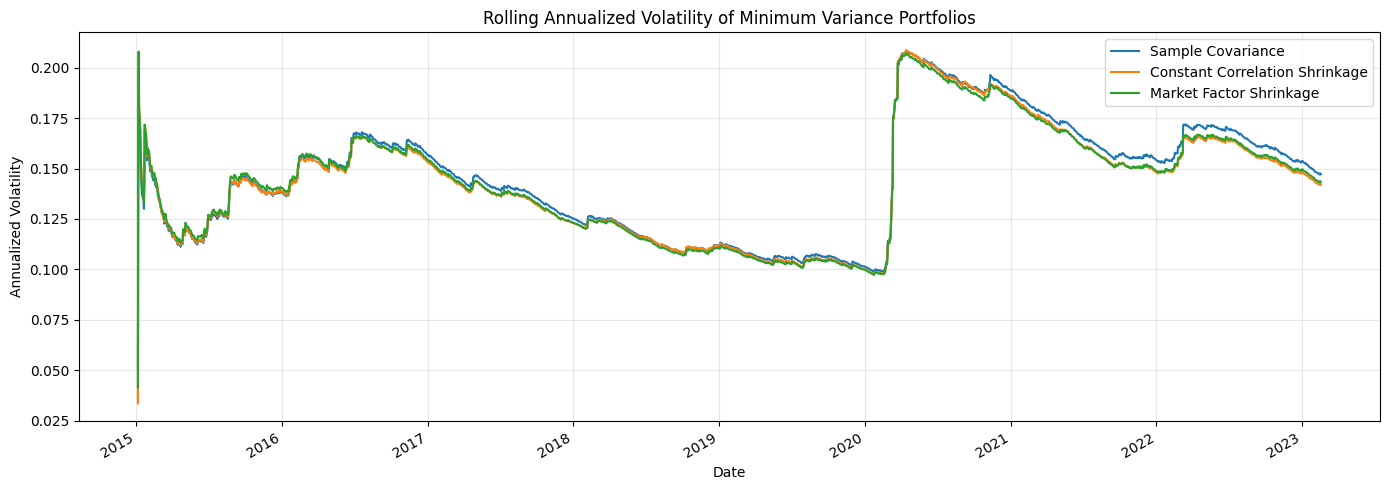

In [95]:
# Plot rolling annualized volatility
plt.figure(figsize=(14, 5))

(
    np.sqrt(252) * sample_cov_min_var_ptf_pfm.pct_change().ewm(span=time_horizon).std()  
).plot(label="Sample Covariance", linewidth=1.5)

(
    np.sqrt(252)
    * constant_corr_cov_min_var_ptf_pfm.pct_change().ewm(span=time_horizon).std()    
).plot(label="Constant Correlation Shrinkage", linewidth=1.5)

(
    np.sqrt(252)
    * mkt_factor_cov_min_var_ptf_pfm.pct_change().ewm(span=time_horizon).std()         
).plot(label="Market Factor Shrinkage", linewidth=1.5)

plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.title("Rolling Annualized Volatility of Minimum Variance Portfolios")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

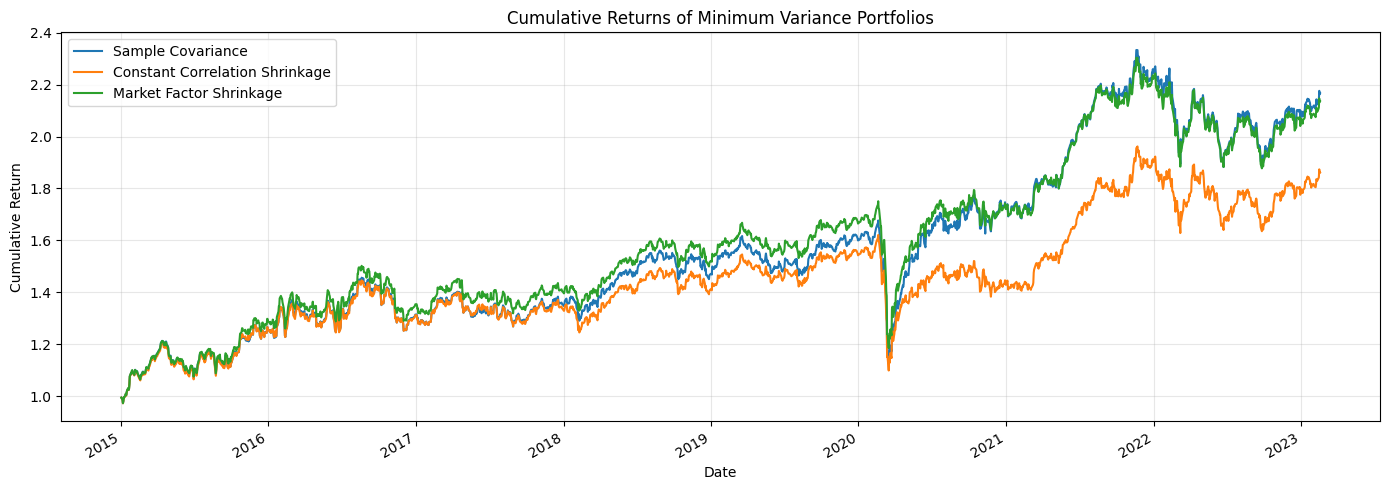

In [96]:
# Plot cumulative returns
plt.figure(figsize=(14, 5))

sample_cov_min_var_ptf_pfm.plot(label="Sample Covariance", linewidth=1.5)
constant_corr_cov_min_var_ptf_pfm.plot(
    label="Constant Correlation Shrinkage", linewidth=1.5
)
mkt_factor_cov_min_var_ptf_pfm.plot(label="Market Factor Shrinkage", linewidth=1.5)

plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Cumulative Returns of Minimum Variance Portfolios")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

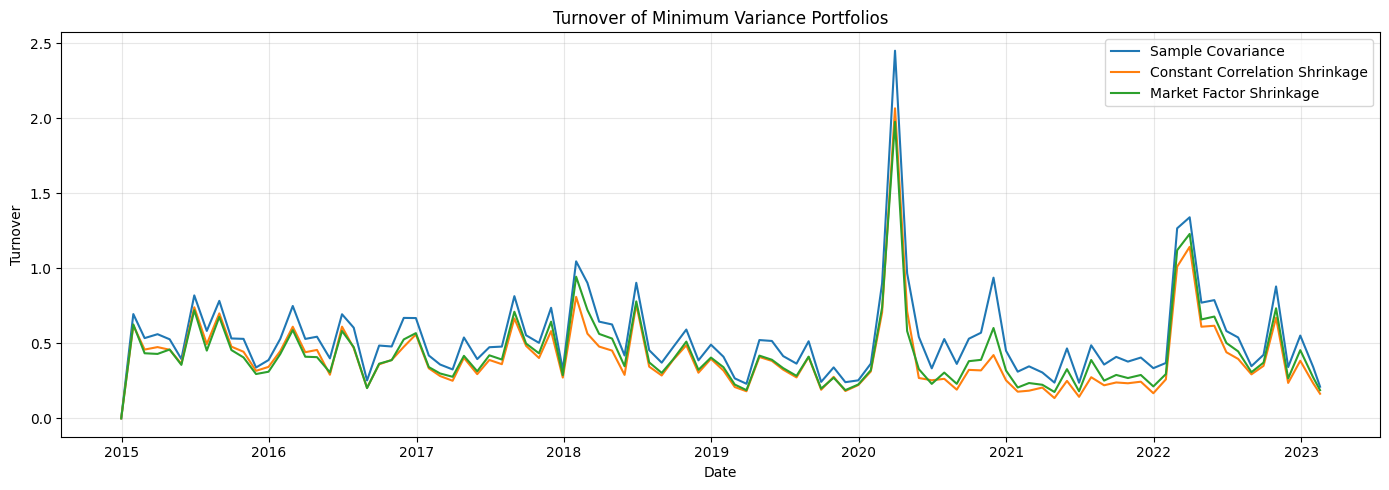

Average Turnover:
  Sample Covariance: 0.53
  Constant Corr Shrinkage: 0.41
  Market Factor Shrinkage: 0.43


In [97]:
# Plot turnover
plt.figure(figsize=(14, 5))

sample_cov_min_var_ptf.diff().abs().sum(axis=1).plot(
    label="Sample Covariance", linewidth=1.5
)
constant_corr_cov_min_var_ptf.diff().abs().sum(axis=1).plot(
    label="Constant Correlation Shrinkage", linewidth=1.5
)
mkt_factor_cov_min_var_ptf.diff().abs().sum(axis=1).plot(
    label="Market Factor Shrinkage", linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("Turnover")
plt.title("Turnover of Minimum Variance Portfolios")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print turnover statistics
print("Average Turnover:")
print(
    f"  Sample Covariance: {sample_cov_min_var_ptf.diff().abs().sum(axis=1).mean():.2f}"
)
print(
    f"  Constant Corr Shrinkage: {constant_corr_cov_min_var_ptf.diff().abs().sum(axis=1).mean():.2f}"
)
print(
    f"  Market Factor Shrinkage: {mkt_factor_cov_min_var_ptf.diff().abs().sum(axis=1).mean():.2f}"
)

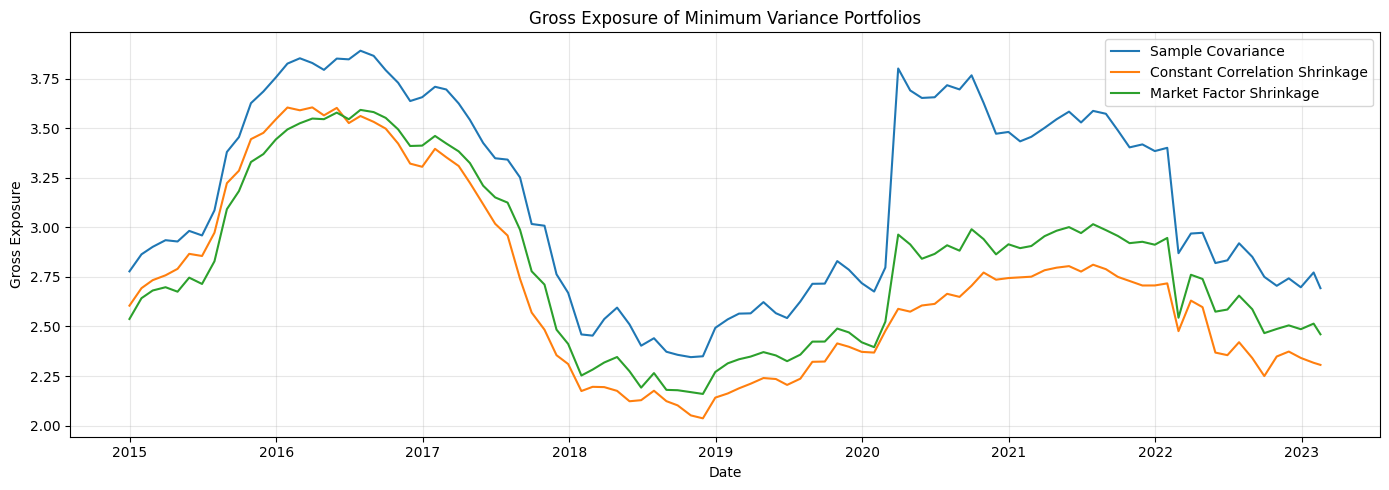

Average Gross Exposure:
  Sample Covariance: 3.14
  Constant Corr Shrinkage: 2.70
  Market Factor Shrinkage: 2.81


In [98]:
# Plot gross exposure
plt.figure(figsize=(14, 5))

sample_cov_min_var_ptf.abs().sum(axis=1).plot(label="Sample Covariance", linewidth=1.5)
constant_corr_cov_min_var_ptf.abs().sum(axis=1).plot(
    label="Constant Correlation Shrinkage", linewidth=1.5
)
mkt_factor_cov_min_var_ptf.abs().sum(axis=1).plot(
    label="Market Factor Shrinkage", linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("Gross Exposure")
plt.title("Gross Exposure of Minimum Variance Portfolios")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print exposure statistics
print("Average Gross Exposure:")
print(f"  Sample Covariance: {sample_cov_min_var_ptf.abs().sum(axis=1).mean():.2f}")
print(
    f"  Constant Corr Shrinkage: {constant_corr_cov_min_var_ptf.abs().sum(axis=1).mean():.2f}"
)
print(
    f"  Market Factor Shrinkage: {mkt_factor_cov_min_var_ptf.abs().sum(axis=1).mean():.2f}"
)

d) Mean-variance portfolios out of sample evaluation


In [99]:
constant_corr_cov_mean_var_ptf = pd.DataFrame(constant_corr_cov_mean_var_ptfs).T.fillna(
    0.0
)
mkt_factor_cov_mean_var_ptf = pd.DataFrame(mkt_factor_cov_mean_var_ptfs).T.fillna(0.0)
sample_cov_mean_var_ptf = pd.DataFrame(sample_cov_mean_var_ptfs).T.fillna(0.0)


In [100]:
# Backtest portfolios
sample_cov_mean_var_ptf_pfm = backtest(
    portfolios=sample_cov_mean_var_ptf,
    returns=performance,
)
constant_corr_cov_mean_var_ptf_pfm = backtest(
    portfolios=constant_corr_cov_mean_var_ptf,
    returns=performance,
)
mkt_factor_cov_mean_var_ptf_pfm = backtest(
    portfolios=mkt_factor_cov_mean_var_ptf,
    returns=performance,
)


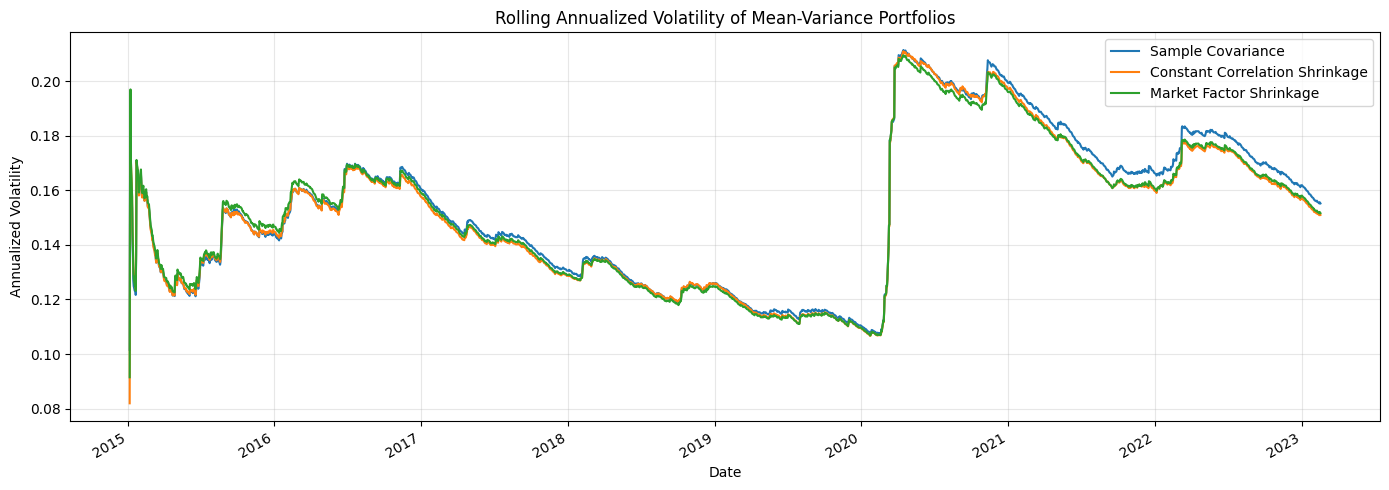

In [101]:
# Plot rolling annualized volatility
plt.figure(figsize=(14, 5))

(
    np.sqrt(252) * sample_cov_mean_var_ptf_pfm.pct_change().ewm(span=time_horizon).std()
).plot(label="Sample Covariance", linewidth=1.5)

(
    np.sqrt(252)
    * constant_corr_cov_mean_var_ptf_pfm.pct_change().ewm(span=time_horizon).std()
).plot(label="Constant Correlation Shrinkage", linewidth=1.5)

(
    np.sqrt(252)
    * mkt_factor_cov_mean_var_ptf_pfm.pct_change().ewm(span=time_horizon).std()
).plot(label="Market Factor Shrinkage", linewidth=1.5)

plt.xlabel("Date")
plt.ylabel("Annualized Volatility")
plt.title("Rolling Annualized Volatility of Mean-Variance Portfolios")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


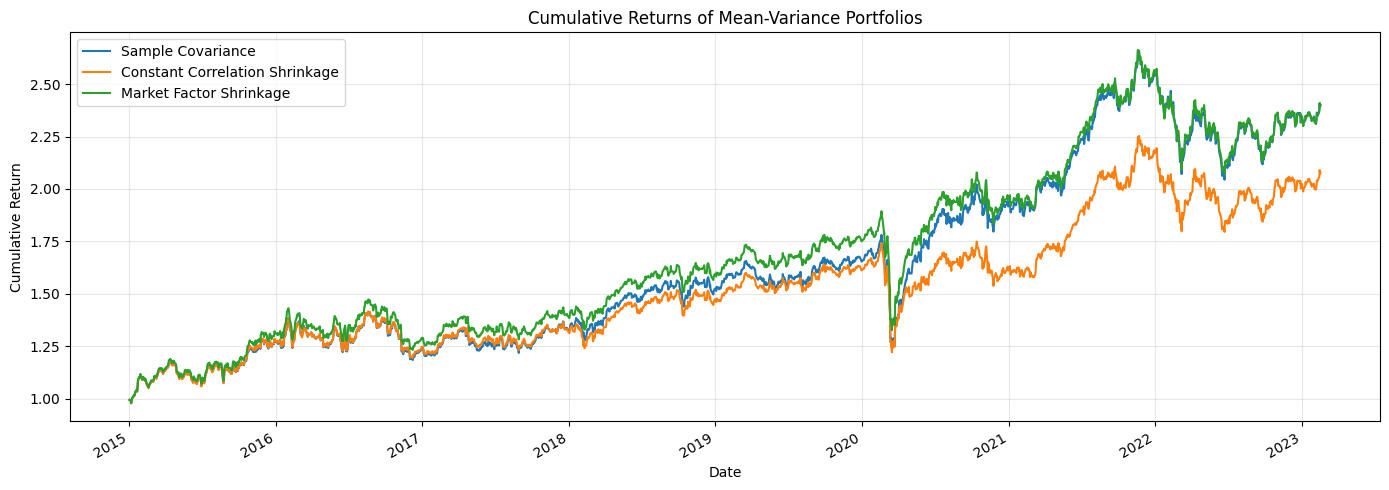

In [102]:
# Plot cumulative returns
plt.figure(figsize=(14, 5))

sample_cov_mean_var_ptf_pfm.plot(label="Sample Covariance", linewidth=1.5)
constant_corr_cov_mean_var_ptf_pfm.plot(
    label="Constant Correlation Shrinkage", linewidth=1.5
)
mkt_factor_cov_mean_var_ptf_pfm.plot(label="Market Factor Shrinkage", linewidth=1.5)

plt.xlabel("Date")
plt.ylabel("Cumulative Return")
plt.title("Cumulative Returns of Mean-Variance Portfolios")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()


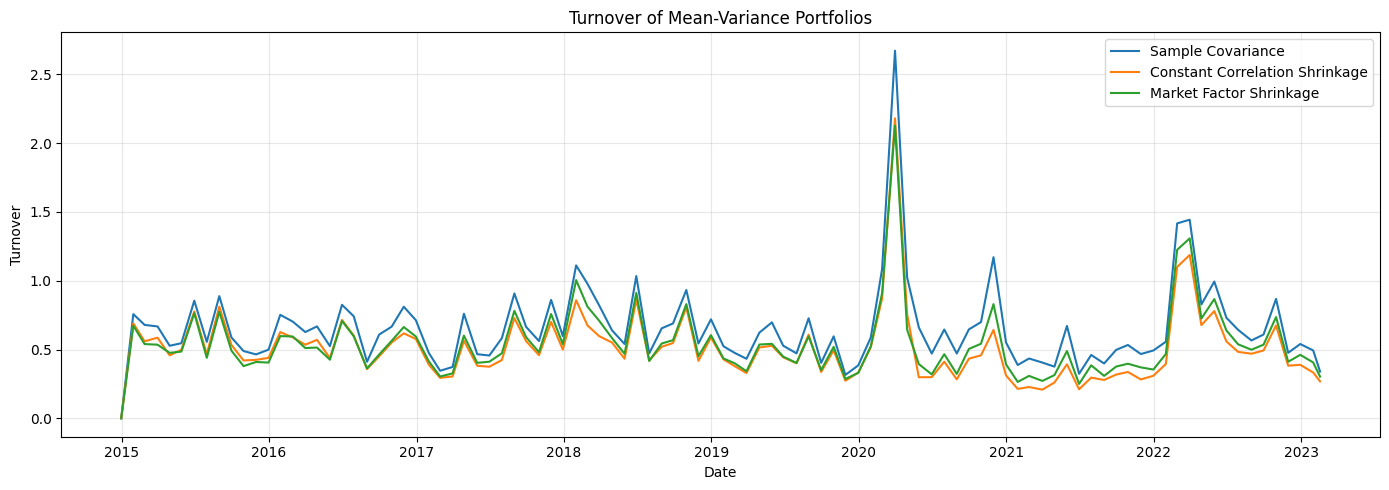

Average Turnover:
  Sample Covariance: 0.65
  Constant Corr Shrinkage: 0.51
  Market Factor Shrinkage: 0.54


In [103]:
# Plot turnover 
plt.figure(figsize=(14, 5))

sample_cov_mean_var_ptf.diff().abs().sum(axis=1).plot(
    label="Sample Covariance", linewidth=1.5
)
constant_corr_cov_mean_var_ptf.diff().abs().sum(axis=1).plot(
    label="Constant Correlation Shrinkage", linewidth=1.5
)
mkt_factor_cov_mean_var_ptf.diff().abs().sum(axis=1).plot(
    label="Market Factor Shrinkage", linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("Turnover")
plt.title("Turnover of Mean-Variance Portfolios")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print turnover statistics
print("Average Turnover:")
print(
    f"  Sample Covariance: {sample_cov_mean_var_ptf.diff().abs().sum(axis=1).mean():.2f}"
)
print(
    f"  Constant Corr Shrinkage: {constant_corr_cov_mean_var_ptf.diff().abs().sum(axis=1).mean():.2f}"
)
print(
    f"  Market Factor Shrinkage: {mkt_factor_cov_mean_var_ptf.diff().abs().sum(axis=1).mean():.2f}"
)

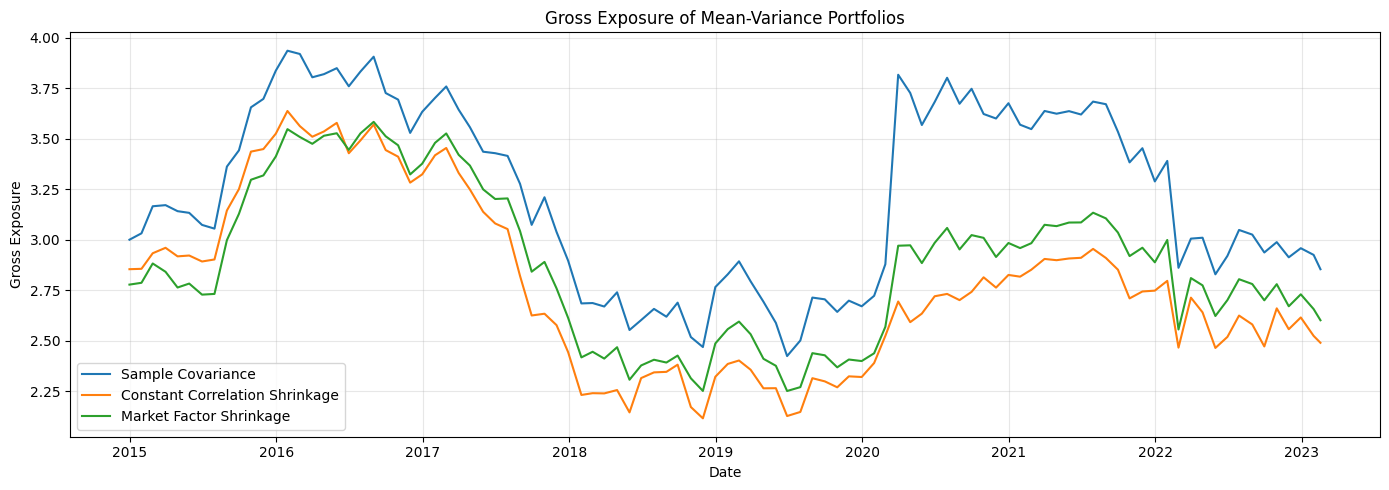

Average Gross Exposure:
  Sample Covariance: 3.22
  Constant Corr Shrinkage: 2.77
  Market Factor Shrinkage: 2.88


In [104]:
# Plot gross exposure
plt.figure(figsize=(14, 5))

sample_cov_mean_var_ptf.abs().sum(axis=1).plot(label="Sample Covariance", linewidth=1.5)
constant_corr_cov_mean_var_ptf.abs().sum(axis=1).plot(
    label="Constant Correlation Shrinkage", linewidth=1.5
)
mkt_factor_cov_mean_var_ptf.abs().sum(axis=1).plot(
    label="Market Factor Shrinkage", linewidth=1.5
)

plt.xlabel("Date")
plt.ylabel("Gross Exposure")
plt.title("Gross Exposure of Mean-Variance Portfolios")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print exposure statistics
print("Average Gross Exposure:")
print(f"  Sample Covariance: {sample_cov_mean_var_ptf.abs().sum(axis=1).mean():.2f}")
print(
    f"  Constant Corr Shrinkage: {constant_corr_cov_mean_var_ptf.abs().sum(axis=1).mean():.2f}"
)
print(
    f"  Market Factor Shrinkage: {mkt_factor_cov_mean_var_ptf.abs().sum(axis=1).mean():.2f}"
)


Shrinkage intensity

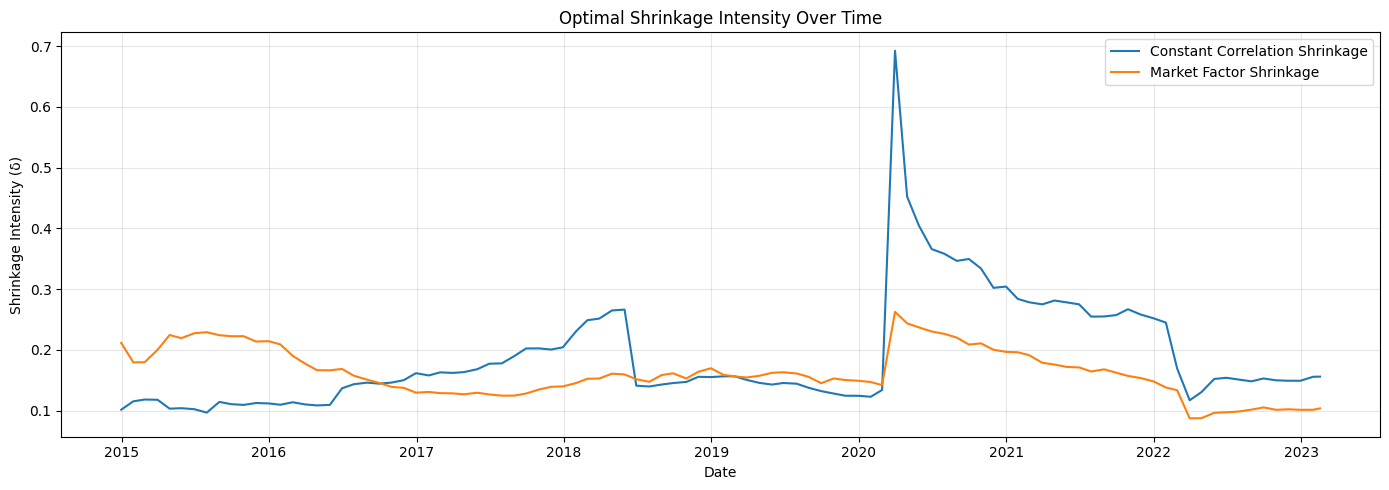

Constant Correlation Shrinkage Intensity:
  Mean: 18.91%
  Std: 9.21%

Market Factor Shrinkage Intensity:
  Mean: 16.21%
  Std: 3.94%


In [105]:
# Plot shrinkage intensity over time
plt.figure(figsize=(14, 5))

pd.Series(
    {date: results["intensity"] for date, results in constant_corr_results.items()}
).plot(label="Constant Correlation Shrinkage", linewidth=1.5)

pd.Series(
    {date: results["intensity"] for date, results in mkt_factor_results.items()}
).plot(label="Market Factor Shrinkage", linewidth=1.5)

plt.xlabel("Date")
plt.ylabel("Shrinkage Intensity (δ)")
plt.title("Optimal Shrinkage Intensity Over Time")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics
const_corr_intensity = pd.Series(
    {date: results["intensity"] for date, results in constant_corr_results.items()}
)
mkt_factor_intensity = pd.Series(
    {date: results["intensity"] for date, results in mkt_factor_results.items()}
)

print("Constant Correlation Shrinkage Intensity:")
print(f"  Mean: {const_corr_intensity.mean():.2%}")
print(f"  Std: {const_corr_intensity.std():.2%}")
print("\nMarket Factor Shrinkage Intensity:")
print(f"  Mean: {mkt_factor_intensity.mean():.2%}")
print(f"  Std: {mkt_factor_intensity.std():.2%}")

Condition Number


In [ ]:
sample_cov_cond = {
    date: np.linalg.cond(results['sample_cov'])
    for date, results in constant_corr_results.items()
}
constant_corr_cond = {
    date: np.linalg.cond(results['shrunk_cov']) 
    for date, results in constant_corr_results.items()
}
mkt_factor_cond = {
    date: np.linalg.cond(results['shrunk_cov'])  
    for date, results in mkt_factor_results.items()
}
eligible_asset_counts = pd.Series(
    {
        date: diagnostics["asset_count_after_filter"]
        for date, diagnostics in window_diagnostics.items()
    }
)


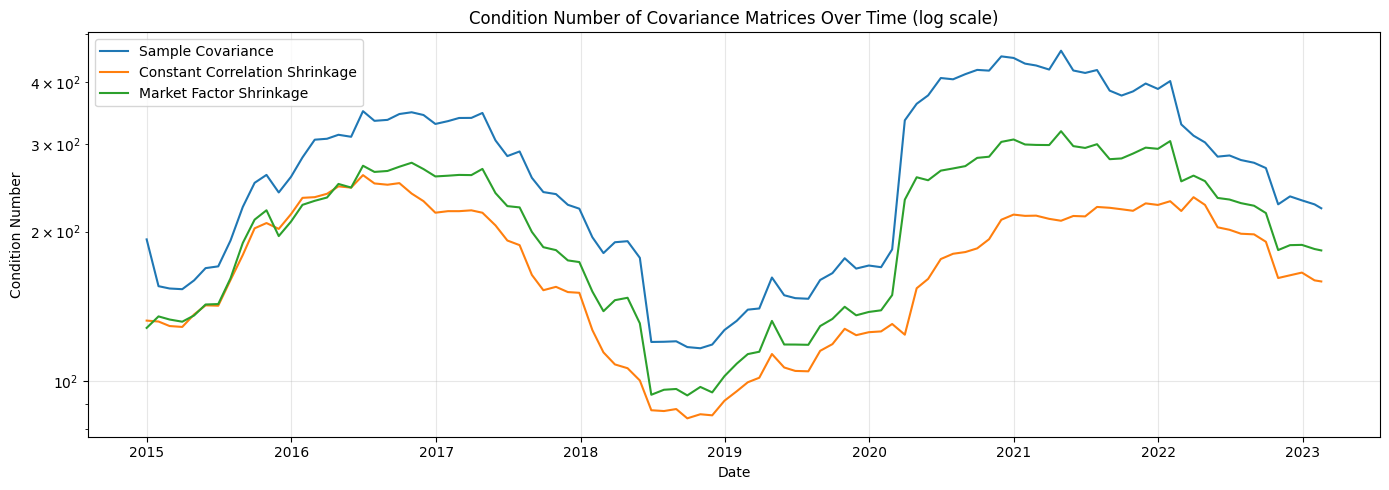

Condition Number Statistics:
  Sample Covariance - Mean: 270.3
  Constant Corr Shrinkage - Mean: 172.9
  Market Factor Shrinkage - Mean: 206.3
  Average number of eligible assets: 47.8


In [107]:
# Plot condition numbers
plt.figure(figsize=(14, 5))

pd.Series(sample_cov_cond).plot(label="Sample Covariance", linewidth=1.5)
pd.Series(constant_corr_cond).plot(
    label="Constant Correlation Shrinkage", linewidth=1.5
)
pd.Series(mkt_factor_cond).plot(label="Market Factor Shrinkage", linewidth=1.5)

plt.xlabel("Date")
plt.ylabel("Condition Number")
plt.yscale("log")
plt.title("Condition Number of Covariance Matrices Over Time (log scale)")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Print statistics
print("Condition Number Statistics:")
print(f"  Sample Covariance - Mean: {np.mean(list(sample_cov_cond.values())):.1f}")
print(
    f"  Constant Corr Shrinkage - Mean: {np.mean(list(constant_corr_cond.values())):.1f}"
)
print(
    f"  Market Factor Shrinkage - Mean: {np.mean(list(mkt_factor_cond.values())):.1f}"
)
print(f"  Average number of eligible assets: {eligible_asset_counts.mean():.1f}")


# Part II: Statistical Factor Model

Principal Component Analysis (PCA) extracts the dominant risk factors from the correlation/covariance matrix. The first principal component typically represents the market factor, explaining a large portion of total variance.

Key properties of PCA:
- Eigenvalues represent variance explained by each component
- Eigenvectors represent factor loadings (exposures of each asset to the factor)
- Components are orthogonal (uncorrelated)

a) PCA

In [108]:
eig_vals = {}
eig_vecs = {}
cosine_distances = {}
max_cosine_distances = {}

prev_eig_vecs = None
for rebalance_date in rebalance_dates:
    cur_performance = prepare_rolling_estimation_window(
        returns=performance,
        rebalance_date=rebalance_date,
        lookback=time_horizon,
        min_coverage=min_coverage,
    )
    if cur_performance.shape[0] < time_horizon or cur_performance.shape[1] == 0:
        continue

    print(
        f"Processing: {rebalance_date.date()} ({cur_performance.shape[1]} assets kept)"
    )
    reb_date = rebalance_date.to_pydatetime().date()

    # Compute covariance matrix and PCA
    sample_cov = cur_performance.cov()
    cur_eig_vals, cur_eig_vecs = principal_component_analysis(sample_cov.values)

    cur_eig_vals = pd.Series(
        data=cur_eig_vals.flatten(), index=range(len(cur_eig_vals))
    )
    cur_eig_vecs = pd.DataFrame(
        data=cur_eig_vecs,
        index=cur_performance.columns,
        columns=range(cur_eig_vecs.shape[1]),
    )
    cur_eig_vecs = align_eigenvectors_to_previous(cur_eig_vecs, prev_eig_vecs)

    # Compute cosine similarity between consecutive periods after sign alignment
    if prev_eig_vecs is not None:
        common_assets = cur_eig_vecs.index.intersection(prev_eig_vecs.index)
        components_num = min(
            len(common_assets),
            cur_eig_vecs.shape[1],
            prev_eig_vecs.shape[1],
        )

        a = cur_eig_vecs.loc[common_assets].iloc[:, :components_num]
        b = prev_eig_vecs.loc[common_assets].iloc[:, :components_num]
        pc_proximity = a.T @ b / (np.linalg.norm(a, axis=0) * np.linalg.norm(b, axis=0))  

        cosine_distances[reb_date] = pd.Series(
            data=np.diag(pc_proximity),
            index=pc_proximity.index,
        )
        max_cosine_distances[reb_date] = pd.Series(
            data=pc_proximity.abs().max(axis=1).values.flatten(),
            index=pc_proximity.index,
        )

    prev_eig_vecs = cur_eig_vecs
    eig_vals[reb_date] = cur_eig_vals
    eig_vecs[reb_date] = cur_eig_vecs


Processing: 2014-12-31 (46 assets kept)
Processing: 2015-01-30 (44 assets kept)
Processing: 2015-02-27 (44 assets kept)
Processing: 2015-03-31 (44 assets kept)
Processing: 2015-04-30 (46 assets kept)
Processing: 2015-05-29 (46 assets kept)
Processing: 2015-06-30 (47 assets kept)
Processing: 2015-07-31 (47 assets kept)
Processing: 2015-08-31 (47 assets kept)
Processing: 2015-09-30 (47 assets kept)
Processing: 2015-10-30 (47 assets kept)
Processing: 2015-11-30 (47 assets kept)
Processing: 2015-12-31 (47 assets kept)
Processing: 2016-01-29 (47 assets kept)
Processing: 2016-02-29 (47 assets kept)
Processing: 2016-03-31 (47 assets kept)
Processing: 2016-04-29 (47 assets kept)
Processing: 2016-05-31 (47 assets kept)
Processing: 2016-06-30 (47 assets kept)
Processing: 2016-07-29 (47 assets kept)
Processing: 2016-08-31 (47 assets kept)
Processing: 2016-09-30 (47 assets kept)
Processing: 2016-10-31 (47 assets kept)
Processing: 2016-11-30 (47 assets kept)
Processing: 2016-12-30 (47 assets kept)


b) Results discussion

Cosine similarity evolution after sign alignment

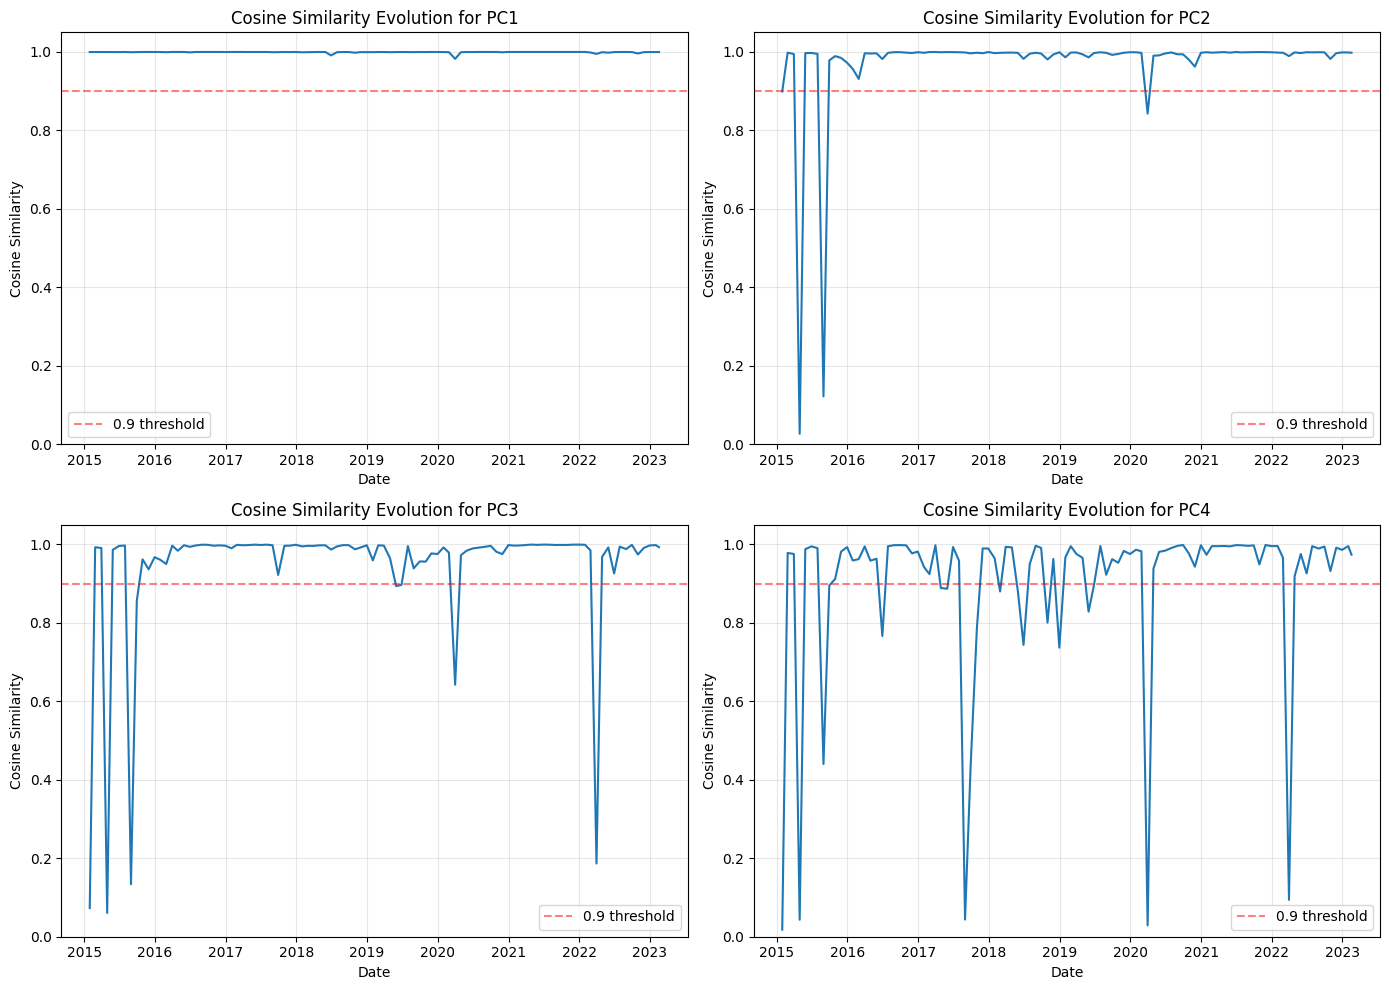

In [109]:
# Plot cosine similarity evolution for the first few PCs
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, pc in enumerate([0, 1, 2, 3]):
    ax = axes[idx // 2, idx % 2]

    cosine_series = pd.Series(
        {
            date: cosine_distance[pc]
            for date, cosine_distance in cosine_distances.items()
        }
    )
    cosine_series.plot(ax=ax, linewidth=1.5)

    ax.set_xlabel("Date")
    ax.set_ylabel("Cosine Similarity")
    ax.set_title(f"Cosine Similarity Evolution for PC{pc + 1}")
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)
    ax.axhline(y=0.9, color="r", linestyle="--", alpha=0.5, label="0.9 threshold")
    ax.legend()

plt.tight_layout()
plt.show()


Explained variance evolution

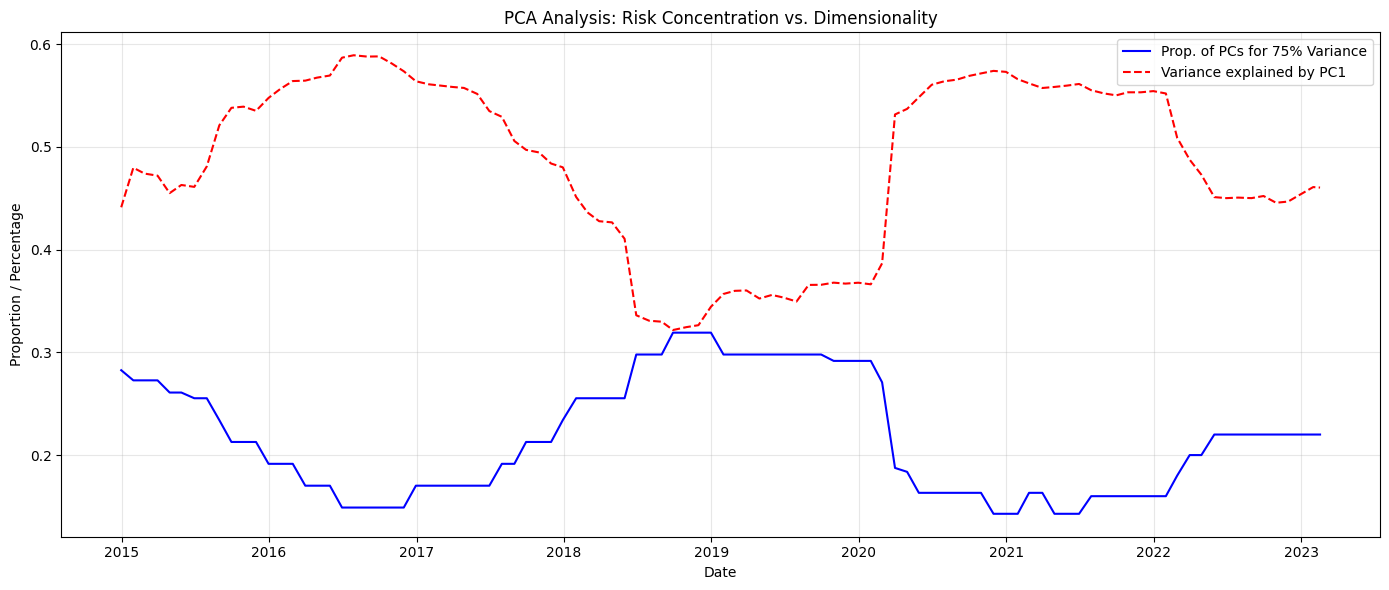

PC1 Variance Statistics:
  Mean PC1 Explained: 48.45%
  Max PC1 Explained:  58.91%


In [110]:
var_threshold = 0.75

pc_proportion = pd.Series(
    {
        date: (np.where(np.cumsum(cur_eig_vals) / np.sum(cur_eig_vals) >= var_threshold)[0][0] + 1) / len(cur_eig_vals)
        for date, cur_eig_vals in eig_vals.items()
    }
)

pc1_variance_explained = pd.Series(
    {
        date: cur_eig_vals[0] / np.sum(cur_eig_vals)
        for date, cur_eig_vals in eig_vals.items()
    }
)

plt.figure(figsize=(14, 6))

pc_proportion.plot(linewidth=1.5, label=f"Prop. of PCs for {var_threshold*100:.0f}% Variance", color='blue')

pc1_variance_explained.plot(linewidth=1.5, label="Variance explained by PC1", color='red', linestyle='--')

plt.xlabel("Date")
plt.ylabel("Proportion / Percentage")
plt.title(f"PCA Analysis: Risk Concentration vs. Dimensionality")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("PC1 Variance Statistics:")
print(f"  Mean PC1 Explained: {pc1_variance_explained.mean():.2%}")
print(f"  Max PC1 Explained:  {pc1_variance_explained.max():.2%}") 

PCs interpretation

The factor loadings (eigenvector components) can be interpreted to understand what each PC represents. Typically:
- **PC1**: Market factor (similar loadings across all assets)
- **PC2+**: Sector/style factors (long-short patterns)

In [111]:
data = pd.Timestamp(year=2019, month=1, day=31)
data = data.to_pydatetime().date()
principal_components = eig_vecs[data].iloc[:, :3]
sector_column = pd.read_csv('C:\\Users\\fabar\\OneDrive\\Desktop\\AssignmentsFINENG\\Assignment3BS_Group2\\data\\ticker_details.csv')



In [112]:
# 1. We perform the merge (ensure that sector_column has the 'GICS' or 'Sector' column)
# We use the column names seen in your previous print output
final_df = pd.merge(
    sector_column[['Ticker', 'GICS']], 
    principal_components.reset_index().rename(columns={'index': 'Ticker'}), 
    on='Ticker', 
    how='right'
)

# 2. We rename columns 0, 1, 2 to PC1, PC2, PC3
final_df = final_df.rename(columns={
    0: 'PC1', 
    1: 'PC2', 
    2: 'PC3',
    'GICS': 'sector' # We also rename the sector column as requested
})

# 3. We set Ticker as the index and keep only the desired columns
final_df = final_df.set_index('Ticker')
final_df = final_df[['PC1', 'PC2', 'PC3', 'sector']]

In [113]:
# 1. Data extraction (Ensure that 'performance' is the returns DataFrame)
historical_data = prepare_rolling_estimation_window(
    returns=performance,
    rebalance_date=pd.Timestamp(year=2019, month=1, day=31),
    lookback=time_horizon,
    min_coverage=0.95
)

# 2. Calculation of market return (simple average of assets in the period)
# It is safer to calculate it directly from the extracted data to ensure alignment
mkt_series = historical_data.mean(axis=1)

# 3. Adding the market to the DF to calculate the covariance
df_with_mkt = historical_data.copy()
df_with_mkt['market'] = mkt_series

# 4. Beta Calculation: Cov(i, m) / Var(m)
cov_matrix = df_with_mkt.cov()
cov_with_mkt = cov_matrix.iloc[:-1, -1] # Takes the last column except for the last row
mkt_variance = cov_matrix.iloc[-1, -1]  # The last element of the diagonal is Var(m)

beta = cov_with_mkt / mkt_variance

# 5. Alignment with your final_df
final_df['beta'] = beta

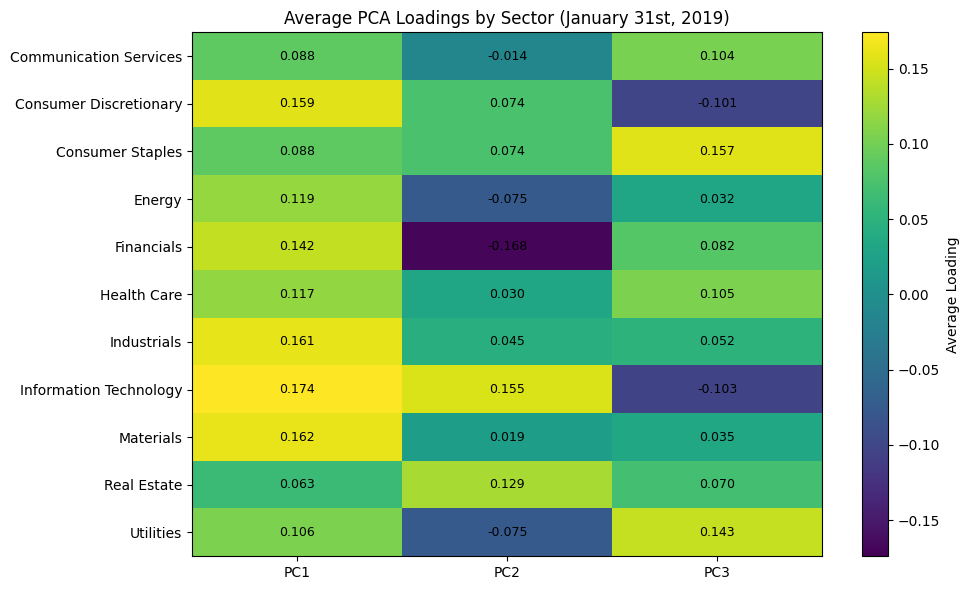

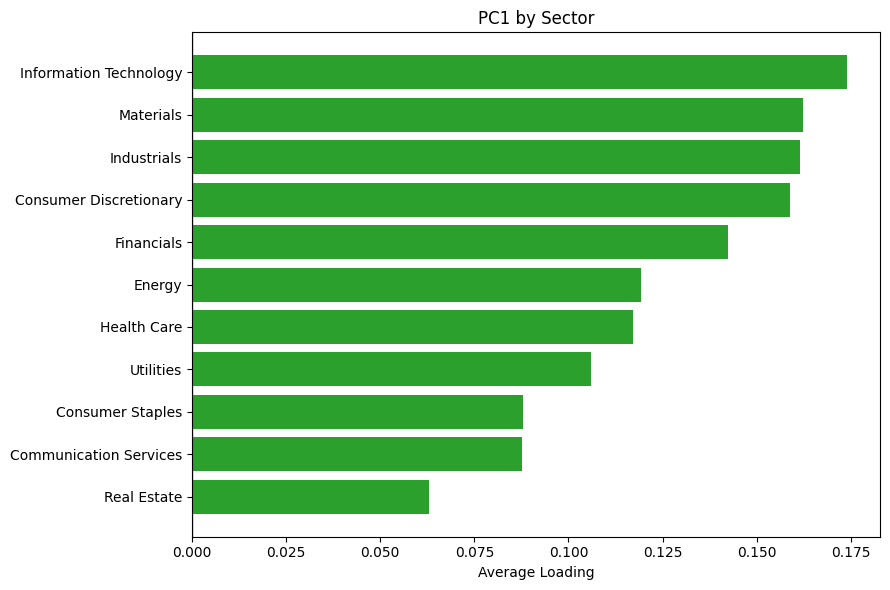

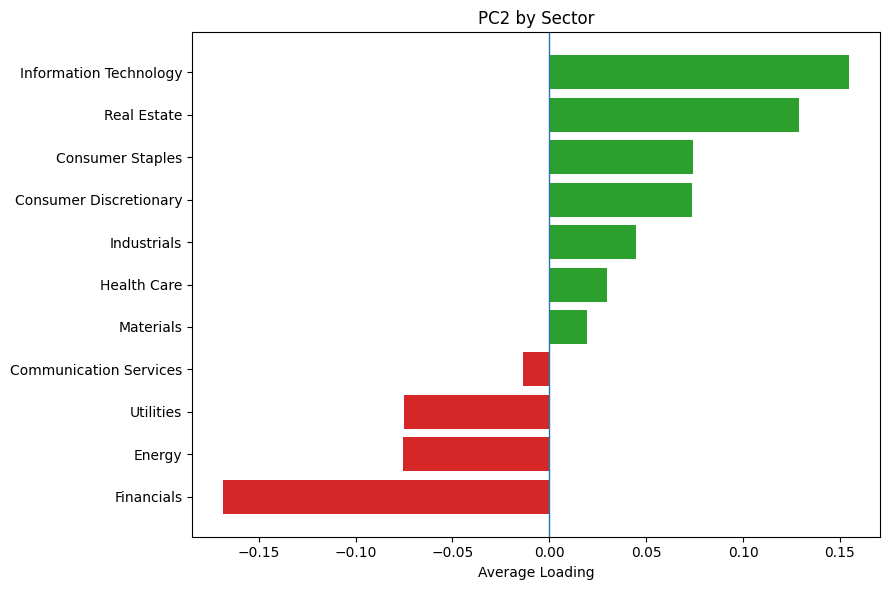

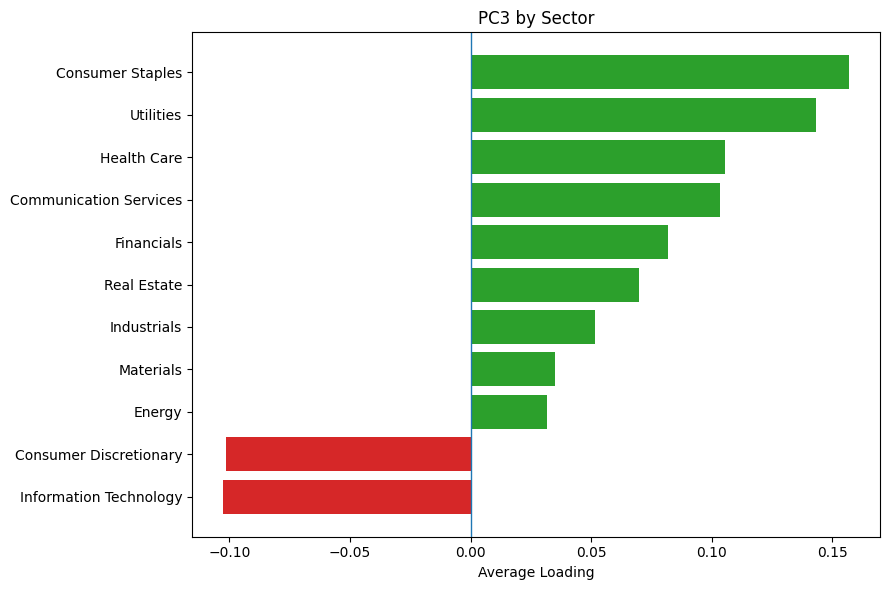

In [114]:
# final_df must contain: PC1, PC2, PC3, sector
sector_loadings = final_df.groupby("sector")[["PC1", "PC2", "PC3"]].mean()

# Optional ordering for readability
sector_loadings_pc1 = sector_loadings.sort_values("PC1")
sector_loadings_pc2 = sector_loadings.sort_values("PC2")
sector_loadings_pc3 = sector_loadings.sort_values("PC3")

# =========================
# 1) Heatmap
# =========================
plt.figure(figsize=(10, 6))

vals = sector_loadings.values
vmax = np.abs(vals).max()
norm = TwoSlopeNorm(vmin=-vmax, vcenter=0.0, vmax=vmax)

plt.imshow(vals, aspect="auto", norm=norm)
plt.xticks(np.arange(sector_loadings.shape[1]), sector_loadings.columns)
plt.yticks(np.arange(sector_loadings.shape[0]), sector_loadings.index)

for i in range(vals.shape[0]):
    for j in range(vals.shape[1]):
        plt.text(j, i, f"{vals[i, j]:.3f}", ha="center", va="center", fontsize=9)

cbar = plt.colorbar()
cbar.set_label("Average Loading")

plt.title("Average PCA Loadings by Sector (January 31st, 2019)")
plt.tight_layout()
plt.show()


# Helper function
def plot_sorted_pc_bar(series: pd.Series, title: str):
    plt.figure(figsize=(9, 6))
    s = series.sort_values()
    colors = ["tab:red" if x < 0 else "tab:green" for x in s.values]
    plt.barh(s.index, s.values, color=colors)
    plt.axvline(0, linewidth=1)
    plt.xlabel("Average Loading")
    plt.title(title)
    plt.tight_layout()
    plt.show()


# =========================
# 2) PC1
# =========================
plot_sorted_pc_bar(
    sector_loadings["PC1"],
    "PC1 by Sector"
)

# =========================
# 3) PC2
# =========================
plot_sorted_pc_bar(
    sector_loadings["PC2"],
    "PC2 by Sector"
)

# =========================
# 4) PC3
# =========================
plot_sorted_pc_bar(
    sector_loadings["PC3"],
    "PC3 by Sector"
)

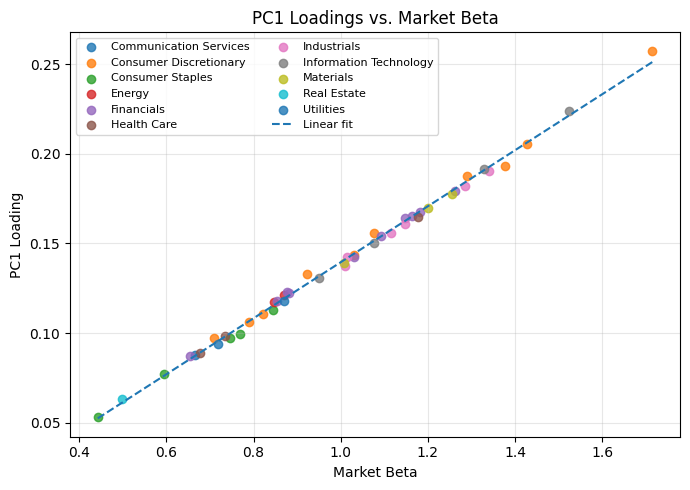

In [115]:
plt.figure(figsize=(7, 5))

plot_df = final_df.dropna(subset=["PC1", "beta"]).copy()

for sector, grp in plot_df.groupby("sector"):
    plt.scatter(
        grp["beta"],
        grp["PC1"],
        label=sector,
        alpha=0.8
    )

x = plot_df["beta"].values
y = plot_df["PC1"].values
coef = np.polyfit(x, y, 1)
x_line = np.linspace(x.min(), x.max(), 100)
y_line = coef[0] * x_line + coef[1]

plt.plot(x_line, y_line, linestyle="--", linewidth=1.5, label="Linear fit")

plt.xlabel("Market Beta")
plt.ylabel("PC1 Loading")
plt.title("PC1 Loadings vs. Market Beta")

plt.legend(
    loc="best",
    fontsize=8,
    ncol=2,          
    frameon=True
)

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# Part III: Connecting the Dots

Shrinkage and PCA-based denoising both address the same problem — the sample covariance matrix is noisy when $T/N$ is not large. They do so in complementary ways:

- **Shrinkage** blends the sample covariance with a structured target, pulling extreme (noisy) eigenvalues toward a common level.
- **PCA denoising** keeps the $k$ largest eigenvalues intact (signal) and replaces the remaining $N - k$ eigenvalues with their average (noise floor), then reconstructs: $$\hat{\Sigma}_{denoised} = \sum_{i=1}^{k} \lambda_i \mathbf{v}_i \mathbf{v}_i^\top + \bar{\lambda}_{noise} \sum_{i=k+1}^{N} \mathbf{v}_i \mathbf{v}_i^\top$$

a) PCA-based denoising of the covariance matrix

In [116]:
data = pd.Timestamp(year=2019, month=1, day=31)
data = data.to_pydatetime().date()

cur_performance = prepare_rolling_estimation_window(
        returns=performance,
        rebalance_date=data,
        lookback=time_horizon,
        min_coverage=min_coverage,
    )
cov_matrix_january = cur_performance.cov()
cov_matrix_denoised_dict = {}
eig_denoised = {}

In [117]:
k_list = [1,3,5,10]
for k in k_list:
    cov_matrix_denoised_dict[k] , eig_denoised[k] = pca_denoise_covariance(cov_matrix_january, k)

analysis_date = pd.Timestamp("2019-01-31")

window_2019 = prepare_rolling_estimation_window(
    returns=performance,
    rebalance_date=analysis_date,
    lookback=time_horizon,
    min_coverage=min_coverage,
)

sample_cov_2019 = window_2019.cov()

cc_results_2019 = constant_corr_shrinkage(returns=window_2019)
mf_results_2019 = market_factor_shrinkage(
    returns=window_2019,
    market_returns=window_2019.mean(axis=1),
)

cc_cov_2019 = cc_results_2019["shrunk_cov"]
mf_cov_2019 = mf_results_2019["shrunk_cov"]

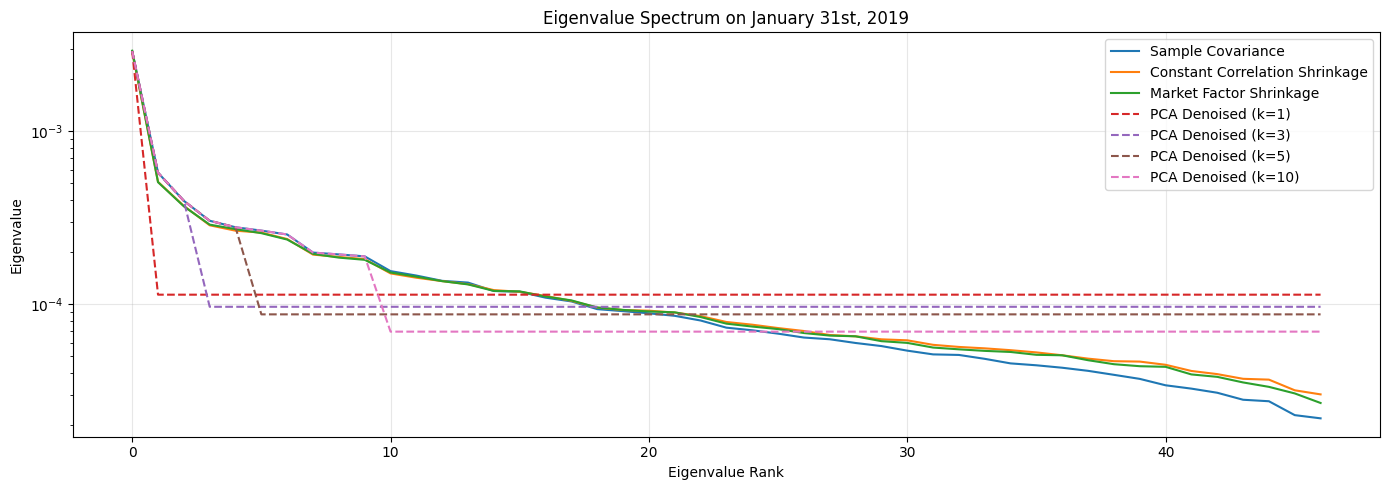

In [118]:
pca_denoised_results = {}
for k in [1, 3, 5, 10]:
    denoised_cov, denoised_eigvals = pca_denoise_covariance(sample_cov_2019.values, k)
    pca_denoised_results[k] = {
        "cov": pd.DataFrame(
            denoised_cov,
            index=sample_cov_2019.index,
            columns=sample_cov_2019.columns,
        ),
        "eigvals": denoised_eigvals,
    }



sample_eigvals, _ = principal_component_analysis(sample_cov_2019.values)
cc_eigvals, _ = principal_component_analysis(cc_cov_2019.values)
mf_eigvals, _ = principal_component_analysis(mf_cov_2019.values)

plt.figure(figsize=(14, 5))
plt.semilogy(sample_eigvals, label="Sample Covariance", linewidth=1.5)
plt.semilogy(cc_eigvals, label="Constant Correlation Shrinkage", linewidth=1.5)
plt.semilogy(mf_eigvals, label="Market Factor Shrinkage", linewidth=1.5)

for k in [1, 3, 5, 10]:
    plt.semilogy(
        pca_denoised_results[k]["eigvals"],
        label=f"PCA Denoised (k={k})",
        linestyle="--",
        linewidth=1.5,
    )

plt.xlabel("Eigenvalue Rank")
plt.ylabel("Eigenvalue")
plt.title("Eigenvalue Spectrum on January 31st, 2019")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

**APPENDIX: PCA ON CORRELATION MATRIX**

In [119]:
eig_vals = {}
eig_vecs = {}
cosine_distances = {}
max_cosine_distances = {}

prev_eig_vecs = None
for rebalance_date in rebalance_dates:
    cur_performance = prepare_rolling_estimation_window(
        returns=performance,
        rebalance_date=rebalance_date,
        lookback=time_horizon,
        min_coverage=min_coverage,
    )
    if cur_performance.shape[0] < time_horizon or cur_performance.shape[1] == 0:
        continue

    print(
        f"Processing: {rebalance_date.date()} ({cur_performance.shape[1]} assets kept)"
    )
    reb_date = rebalance_date.to_pydatetime().date()

    # Compute CORRELATION matrix and PCA
    sample_cov_corr = cur_performance.corr()
    cur_eig_vals, cur_eig_vecs = principal_component_analysis(sample_cov_corr.values)

    cur_eig_vals = pd.Series(
        data=cur_eig_vals.flatten(), index=range(len(cur_eig_vals))
    )
    cur_eig_vecs = pd.DataFrame(
        data=cur_eig_vecs,
        index=cur_performance.columns,
        columns=range(cur_eig_vecs.shape[1]),
    )
    cur_eig_vecs = align_eigenvectors_to_previous(cur_eig_vecs, prev_eig_vecs)

    # Compute cosine similarity between consecutive periods after sign alignment
    if prev_eig_vecs is not None:
        common_assets = cur_eig_vecs.index.intersection(prev_eig_vecs.index)
        components_num = min(
            len(common_assets),
            cur_eig_vecs.shape[1],
            prev_eig_vecs.shape[1],
        )

        a = cur_eig_vecs.loc[common_assets].iloc[:, :components_num]
        b = prev_eig_vecs.loc[common_assets].iloc[:, :components_num]
        a_normed = a / np.linalg.norm(a, axis=1)
        b_normed = b / np.linalg.norm(b, axis=1)
        pc_proximity = a_normed.T @ b_normed  

        cosine_distances[reb_date] = pd.Series(
            data=np.diag(pc_proximity),
            index=pc_proximity.index,
        )
        max_cosine_distances[reb_date] = pd.Series(
            data=pc_proximity.abs().max(axis=1).values.flatten(),
            index=pc_proximity.index,
        )

    prev_eig_vecs = cur_eig_vecs
    eig_vals[reb_date] = cur_eig_vals
    eig_vecs[reb_date] = cur_eig_vecs



Processing: 2014-12-31 (46 assets kept)
Processing: 2015-01-30 (44 assets kept)
Processing: 2015-02-27 (44 assets kept)
Processing: 2015-03-31 (44 assets kept)
Processing: 2015-04-30 (46 assets kept)
Processing: 2015-05-29 (46 assets kept)
Processing: 2015-06-30 (47 assets kept)
Processing: 2015-07-31 (47 assets kept)
Processing: 2015-08-31 (47 assets kept)
Processing: 2015-09-30 (47 assets kept)
Processing: 2015-10-30 (47 assets kept)
Processing: 2015-11-30 (47 assets kept)
Processing: 2015-12-31 (47 assets kept)
Processing: 2016-01-29 (47 assets kept)
Processing: 2016-02-29 (47 assets kept)
Processing: 2016-03-31 (47 assets kept)
Processing: 2016-04-29 (47 assets kept)
Processing: 2016-05-31 (47 assets kept)
Processing: 2016-06-30 (47 assets kept)
Processing: 2016-07-29 (47 assets kept)
Processing: 2016-08-31 (47 assets kept)
Processing: 2016-09-30 (47 assets kept)
Processing: 2016-10-31 (47 assets kept)
Processing: 2016-11-30 (47 assets kept)
Processing: 2016-12-30 (47 assets kept)


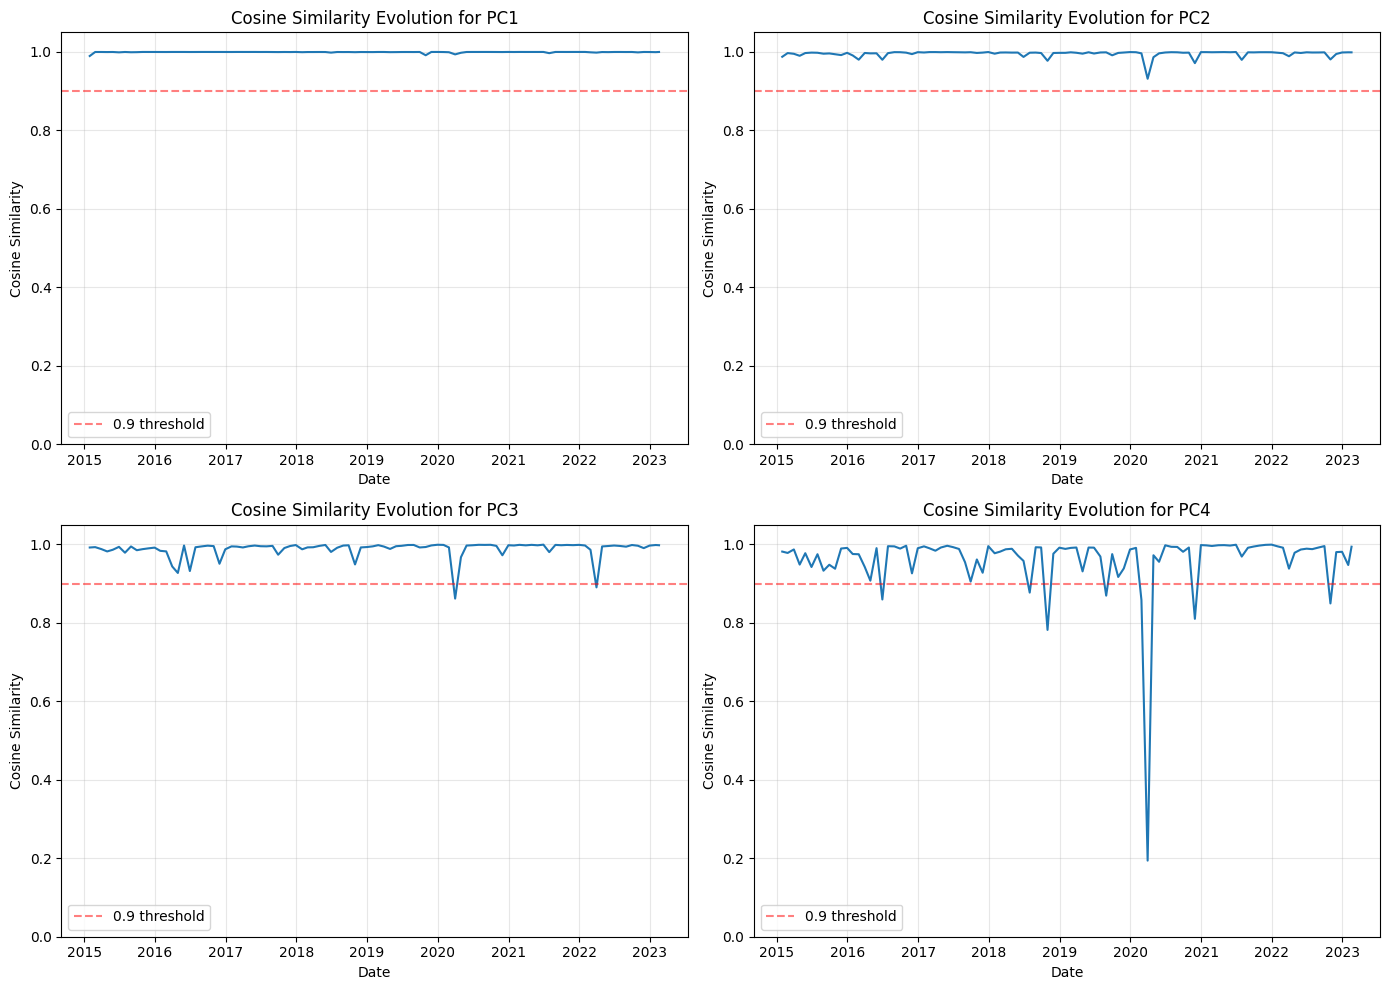

In [120]:
# Plot cosine similarity evolution for the first few PCs
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for idx, pc in enumerate([0, 1, 2, 3]):
    ax = axes[idx // 2, idx % 2]

    cosine_series = pd.Series(
        {
            date: cosine_distance[pc]
            for date, cosine_distance in cosine_distances.items()
        }
    )
    cosine_series.plot(ax=ax, linewidth=1.5)

    ax.set_xlabel("Date")
    ax.set_ylabel("Cosine Similarity")
    ax.set_title(f"Cosine Similarity Evolution for PC{pc + 1}")
    ax.set_ylim(0, 1.05)
    ax.grid(alpha=0.3)
    ax.axhline(y=0.9, color="r", linestyle="--", alpha=0.5, label="0.9 threshold")
    ax.legend()

plt.tight_layout()
plt.show()


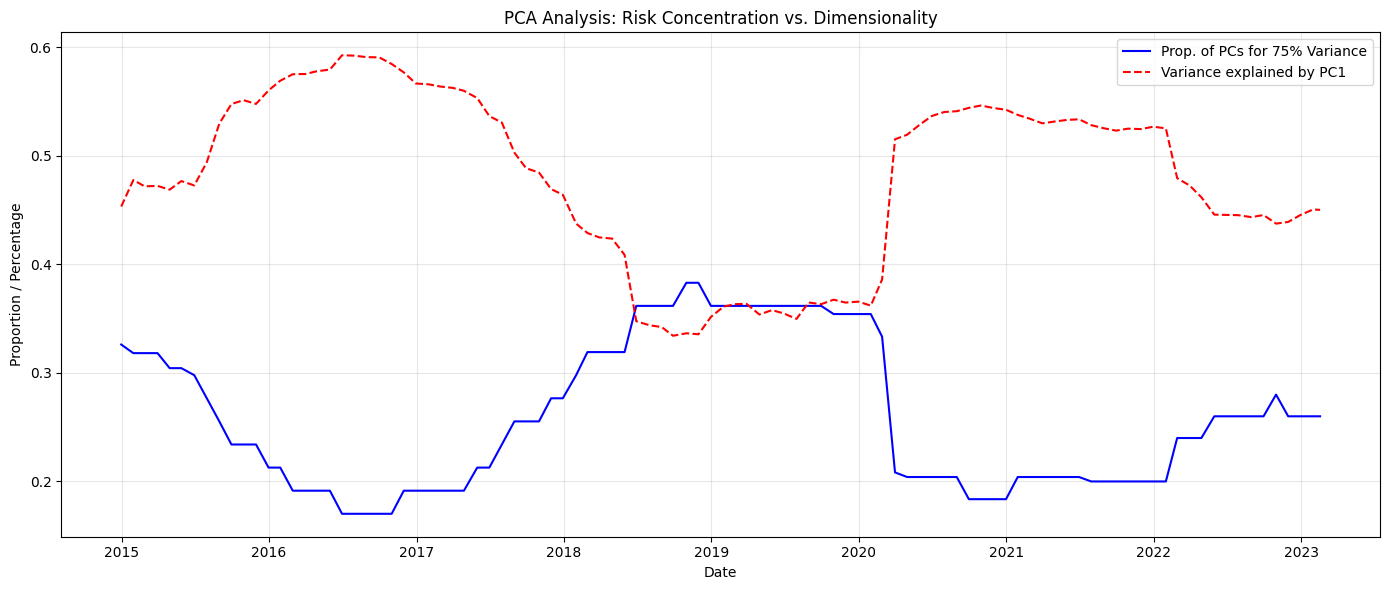

PC1 Variance Statistics:
  Mean PC1 Explained: 47.94%
  Max PC1 Explained:  59.25%


In [121]:
var_threshold = 0.75

pc_proportion = pd.Series(
    {
        date: (np.where(np.cumsum(cur_eig_vals) / np.sum(cur_eig_vals) >= var_threshold)[0][0] + 1) / len(cur_eig_vals)
        for date, cur_eig_vals in eig_vals.items()
    }
)

pc1_variance_explained = pd.Series(
    {
        date: cur_eig_vals[0] / np.sum(cur_eig_vals)
        for date, cur_eig_vals in eig_vals.items()
    }
)

plt.figure(figsize=(14, 6))

pc_proportion.plot(linewidth=1.5, label=f"Prop. of PCs for {var_threshold*100:.0f}% Variance", color='blue')

pc1_variance_explained.plot(linewidth=1.5, label="Variance explained by PC1", color='red', linestyle='--')

plt.xlabel("Date")
plt.ylabel("Proportion / Percentage")
plt.title(f"PCA Analysis: Risk Concentration vs. Dimensionality")
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

print("PC1 Variance Statistics:")
print(f"  Mean PC1 Explained: {pc1_variance_explained.mean():.2%}")
print(f"  Max PC1 Explained:  {pc1_variance_explained.max():.2%}") # Indica momenti di stress

In [122]:
principal_components = eig_vecs[data].iloc[:, :3]
# 1. We perform the merge (ensure that sector_column has the 'GICS' or 'Sector' column)
# We use the column names seen in your previous print output
final_df_2 = pd.merge(
    sector_column[['Ticker', 'GICS']], 
    principal_components.reset_index().rename(columns={'index': 'Ticker'}), 
    on='Ticker', 
    how='right'
)

# 2. We rename columns 0, 1, 2 to PC1, PC2, PC3
final_df_2 = final_df_2.rename(columns={
    0: 'PC1', 
    1: 'PC2', 
    2: 'PC3',
    'GICS': 'sector' # We also rename the sector column as requested
})

# 3. We set Ticker as the index and keep only the desired columns
final_df_2 = final_df_2.set_index('Ticker')
final_df_2 = final_df_2[['PC1', 'PC2', 'PC3', 'sector']]

# 1. Data extraction (Ensure that 'performance' is the returns DataFrame)
historical_data = prepare_rolling_estimation_window(
    returns=performance,
    rebalance_date=pd.Timestamp(year=2019, month=1, day=31),
    lookback=time_horizon,
    min_coverage=0.95
)

# 2. Calculation of market return (simple average of assets in the period)
# It is safer to calculate it directly from the extracted data to ensure alignment
mkt_series = historical_data.mean(axis=1)

# 3. Adding the market to the DF to calculate the covariance
df_with_mkt = historical_data.copy()
df_with_mkt['market'] = mkt_series

# 4. Beta Calculation: Cov(i, m) / Var(m)
cov_matrix = df_with_mkt.cov()
cov_with_mkt = cov_matrix.iloc[:-1, -1] # Takes the last column except for the last row
mkt_variance = cov_matrix.iloc[-1, -1]  # The last element of the diagonal is Var(m)

beta = cov_with_mkt / mkt_variance

# 5. Alignment with your final_df_2
final_df_2['beta'] = beta

# Definition of the columns of interest
cols = ['PC1', 'PC2', 'PC3']

# Function to print statistics in an orderly fashion
def print_pca_stats(df, name):
    print(f"--- Statistics for {name} ---")
    # We select only the PC columns and calculate the requested metrics
    stats = df[cols].agg(['mean', 'min', 'max', 'std'])
    print(stats)
    print("\n")

# Assuming that final_df and final_df_2 are already defined in your environment
print_pca_stats(final_df, "Final DF (Covariance Based)")
print_pca_stats(final_df_2, "Final DF 2 (Correlation Based)")

--- Statistics for Final DF (Covariance Based) ---
           PC1       PC2       PC3
mean  0.139535  0.005845  0.030474
min   0.053183 -0.376843 -0.639786
max   0.257455  0.323108  0.207441
std   0.042964  0.147324  0.144188


--- Statistics for Final DF 2 (Correlation Based) ---
           PC1       PC2       PC3
mean  0.142906 -0.009497 -0.009116
min   0.061318 -0.240722 -0.307173
max   0.190385  0.291099  0.254220
std   0.029545  0.147129  0.147154


